# Домашняя работа 4
Визуализация данных: датасет о выживаемости на Титанике (train.csv)

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Распределение значений признаков Survived, Pclass, Age, Sex, Parch
Для каждого признака построим график распределения.

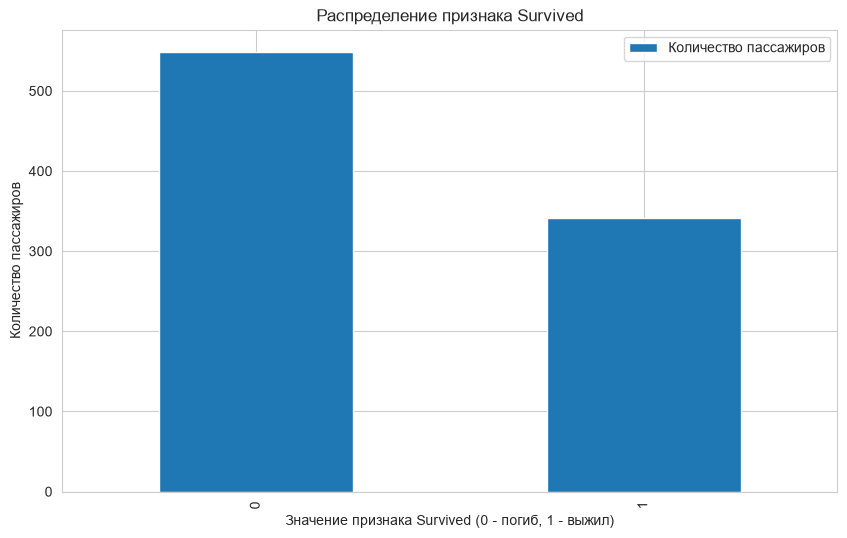

In [2]:
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
df['Survived'].value_counts().plot(kind='bar')
plt.title('Распределение признака Survived')
plt.xlabel('Значение признака Survived (0 - погиб, 1 - выжил)')
plt.ylabel('Количество пассажиров')
plt.legend(['Количество пассажиров'])
plt.show()

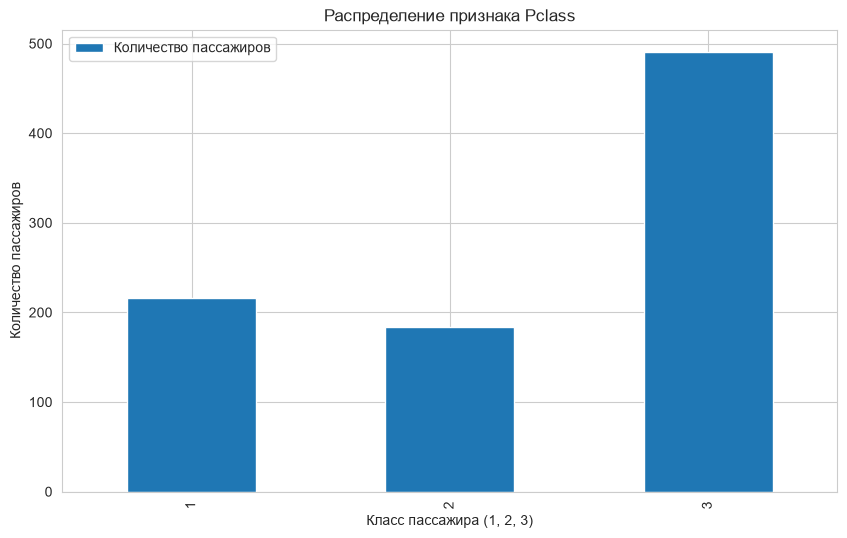

In [3]:
plt.figure(figsize=(10, 6))
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение признака Pclass')
plt.xlabel('Класс пассажира (1, 2, 3)')
plt.ylabel('Количество пассажиров')
plt.legend(['Количество пассажиров'])
plt.show()

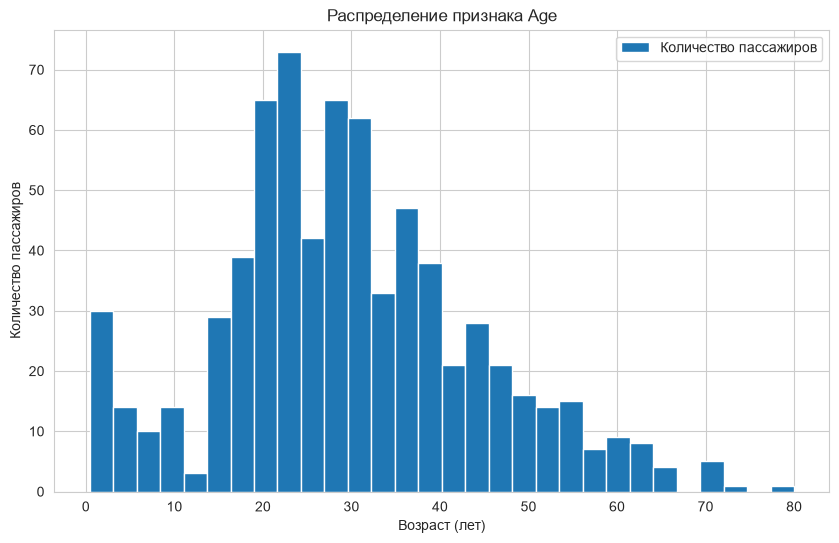

In [4]:
plt.figure(figsize=(10, 6))
df['Age'].hist(bins=30)
plt.title('Распределение признака Age')
plt.xlabel('Возраст (лет)')
plt.ylabel('Количество пассажиров')
plt.legend(['Количество пассажиров'])
plt.show()

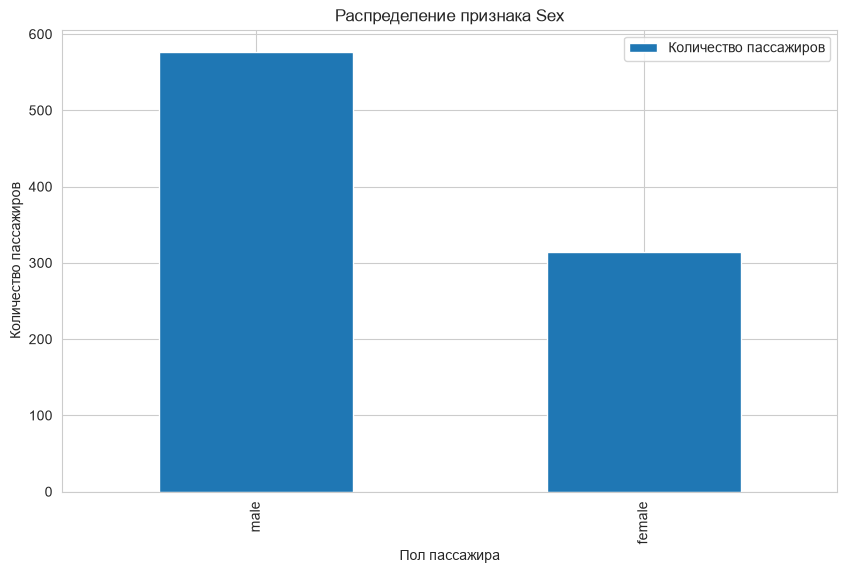

In [5]:
plt.figure(figsize=(10, 6))
df['Sex'].value_counts().plot(kind='bar')
plt.title('Распределение признака Sex')
plt.xlabel('Пол пассажира')
plt.ylabel('Количество пассажиров')
plt.legend(['Количество пассажиров'])
plt.show()

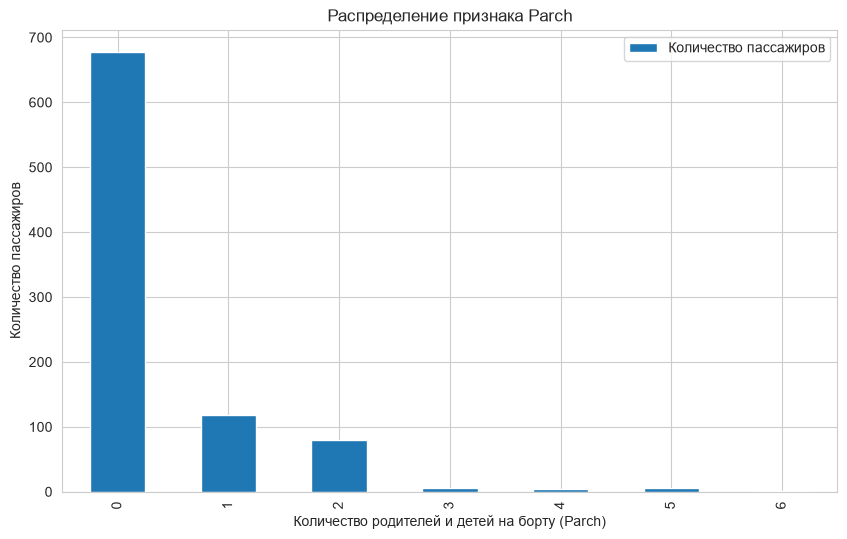

In [6]:
plt.figure(figsize=(10, 6))
df['Parch'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение признака Parch')
plt.xlabel('Количество родителей и детей на борту (Parch)')
plt.ylabel('Количество пассажиров')
plt.legend(['Количество пассажиров'])
plt.show()

## 2. Boxplot для столбца Age
Построим boxplot (ящик с усами), чтобы посмотреть на распределение возраста.

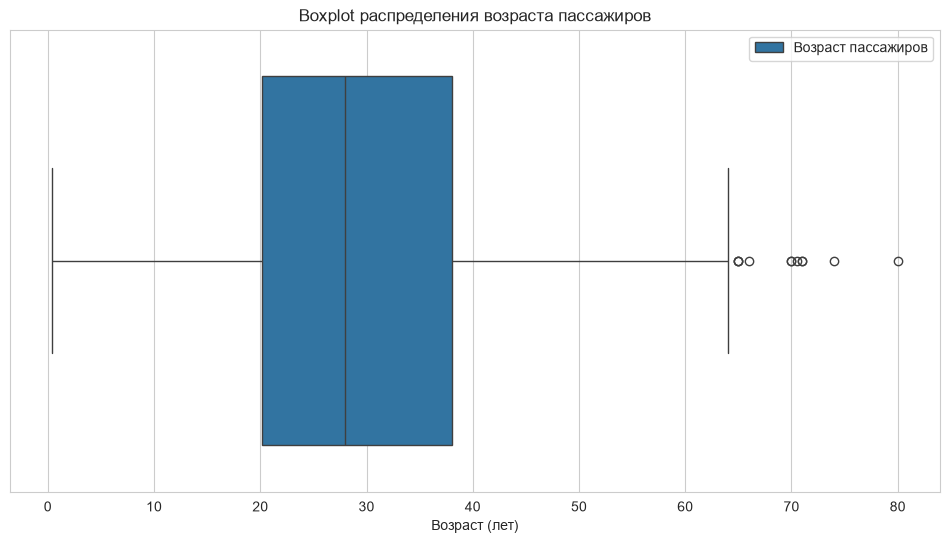

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Age'], label='Возраст пассажиров')
plt.title('Boxplot распределения возраста пассажиров')
plt.xlabel('Возраст (лет)')
plt.legend()
plt.show()

### Интерпретация boxplot
- Линия внутри ящика - это **медиана** возраста, она примерно равна 28 годам, то есть половина пассажиров была моложе 28 лет, а половина - старше.
- Границы ящика - это первый (Q1) и третий (Q3) квартили (примерно 20 и 38 лет). Внутри ящика находятся 50% всех пассажиров, то есть большая часть пассажиров была в возрасте от 20 до 38 лет.
- Усы показывают размах данных до 1.5 межквартильного размаха (IQR), примерно до 65 лет.
- Точки справа от правого уса - это **выбросы**: аномально пожилые пассажиры, возраст которых сильно отличается от основной массы (самые старые - около 80 лет).

## 3. Pie chart для переменных Survived и Pclass
Круговые диаграммы с подписями долей в процентах.

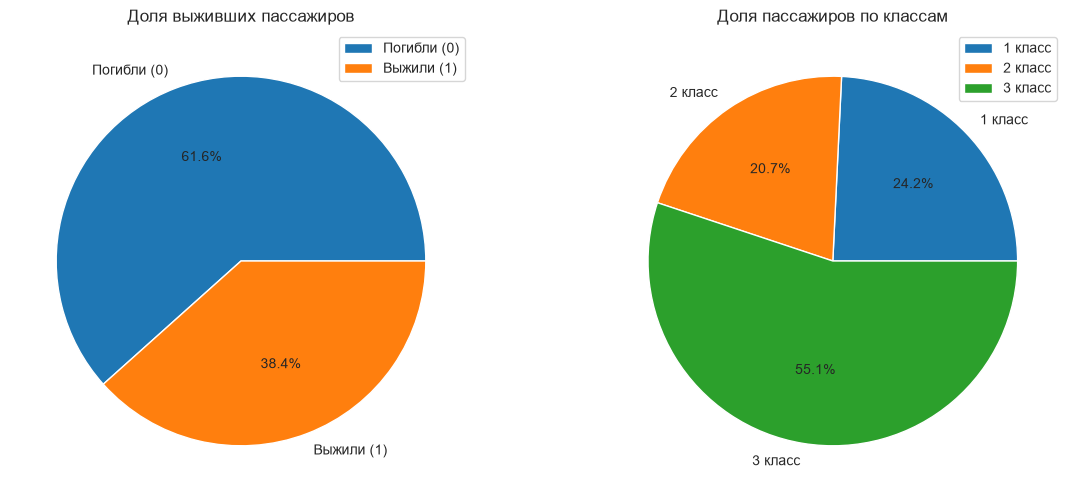

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df['Survived'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                  labels=['Погибли (0)', 'Выжили (1)'], legend=True)
axes[0].set_title('Доля выживших пассажиров')
axes[0].set_ylabel('')

df['Pclass'].value_counts().sort_index().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                              labels=['1 класс', '2 класс', '3 класс'], legend=True)
axes[1].set_title('Доля пассажиров по классам')
axes[1].set_ylabel('')

plt.show()

## 4. Pairplot для всех числовых переменных
Попарные графики распределений для всех числовых колонок датасета.

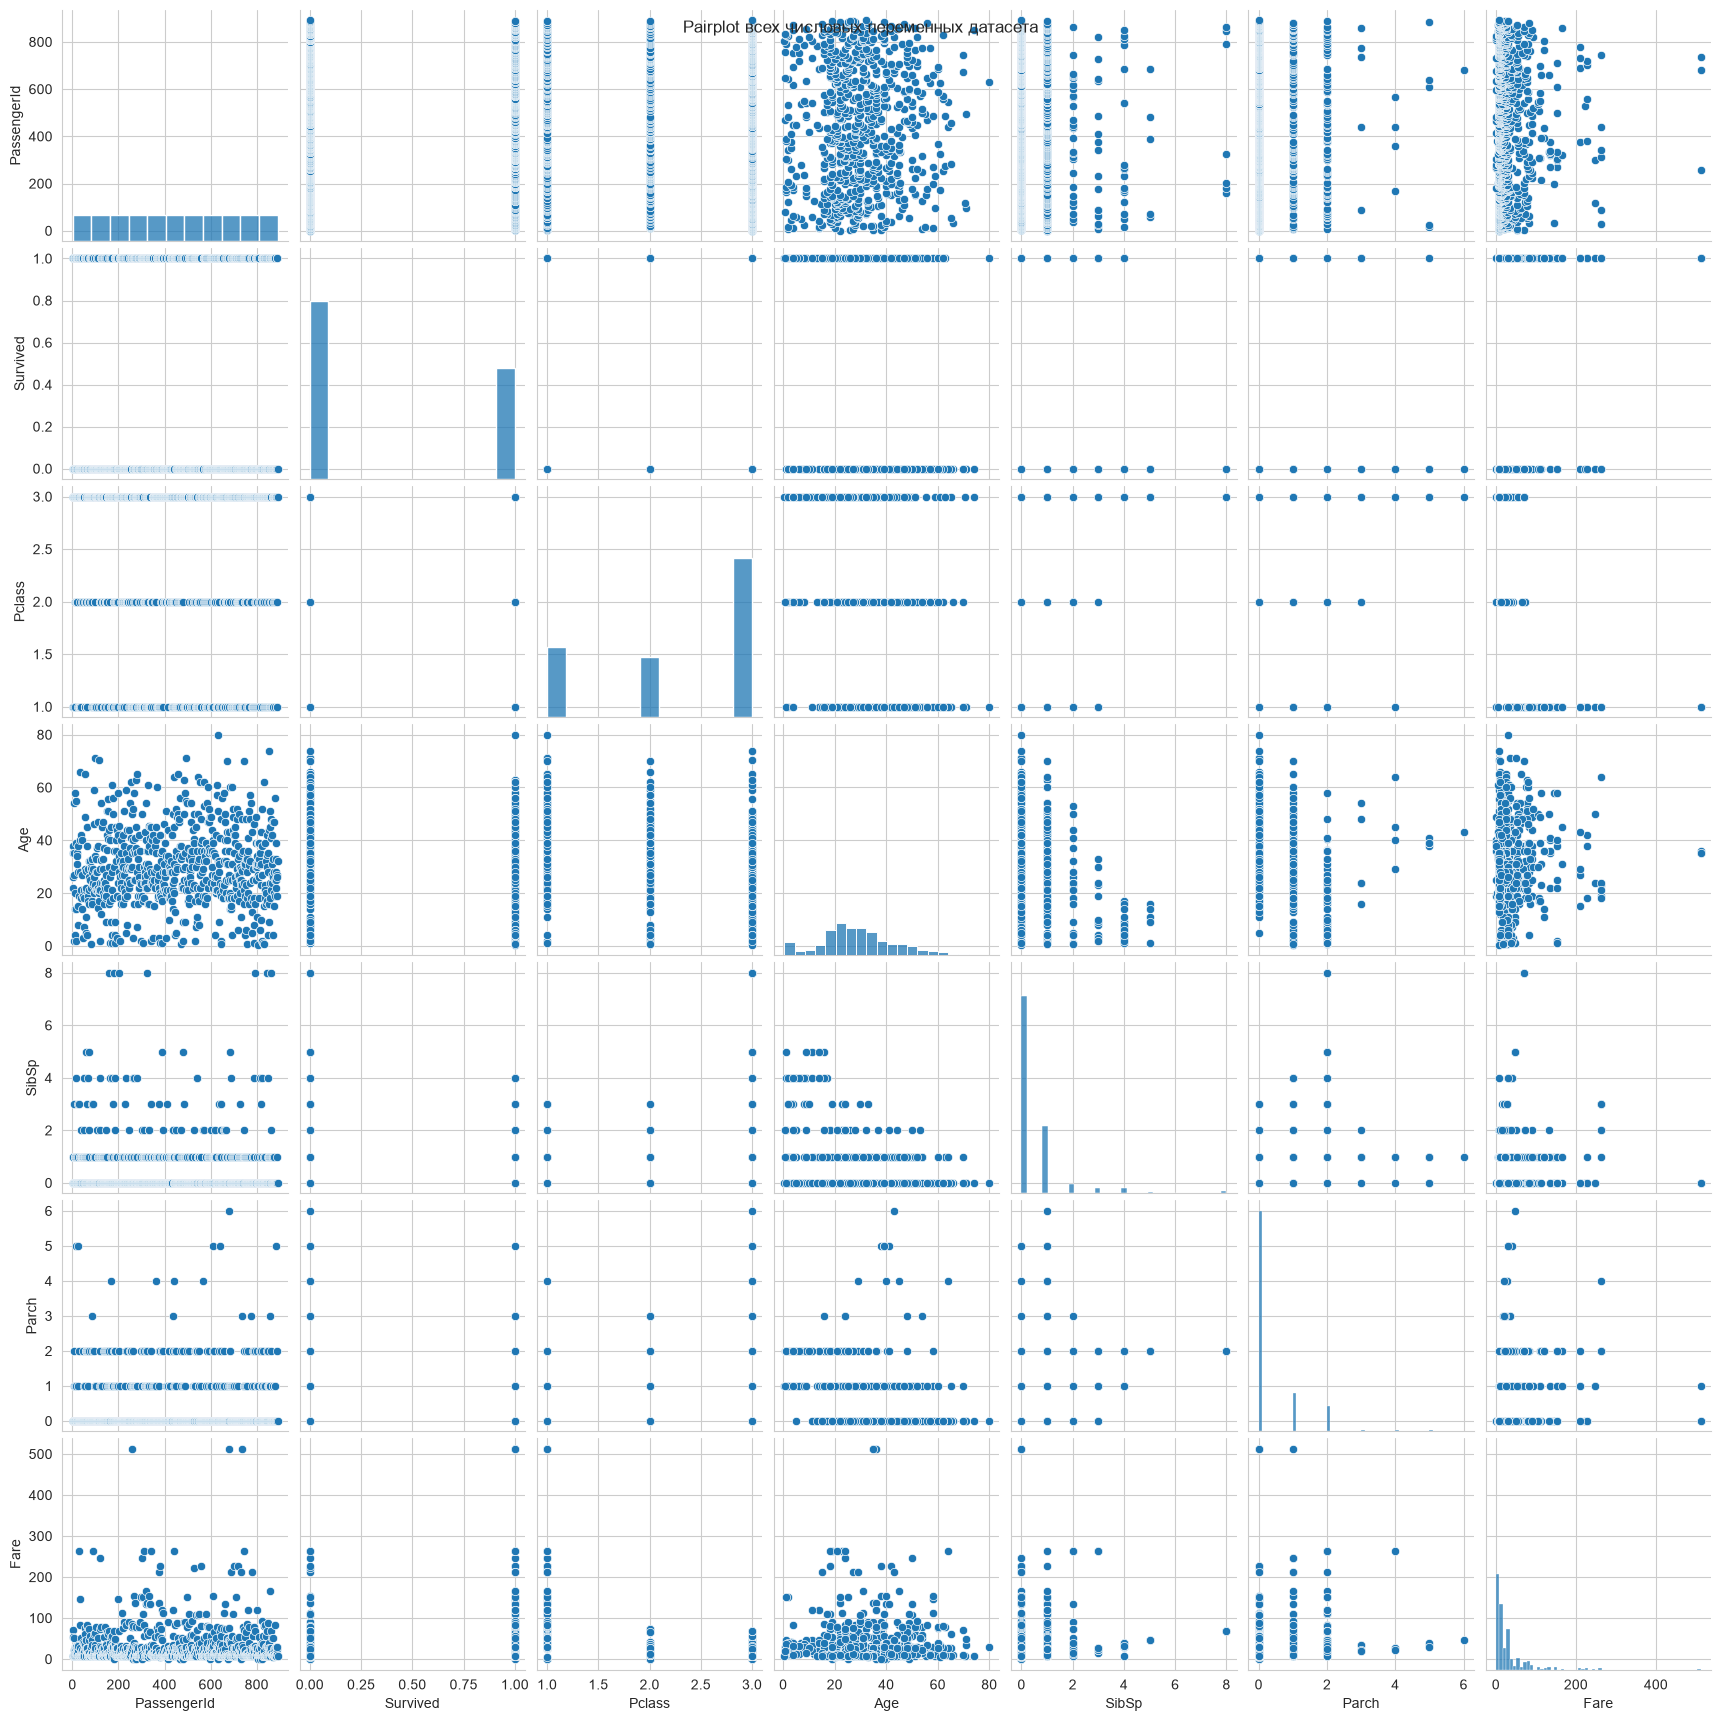

In [9]:
sns.pairplot(df)
plt.suptitle('Pairplot всех числовых переменных датасета')
plt.show()

## 5. Интерактивный Sunburst plot (класс -> пол)
Первый уровень иерархии - количество пассажиров в каждом классе, второй уровень - сколько среди них женщин и мужчин.

In [10]:
data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
fig = px.sunburst(data, path=['Pclass', 'Sex'], values='count',
                  title='Количество пассажиров по классам и полу')
fig.show()

## Выводы
- В 3 классе было больше всего пассажиров (491 из 891), а выживаемость там самая низкая.
- Мужчин на корабле было заметно больше, чем женщин (577 против 314).
- Большинство пассажиров были в возрасте от 20 до 38 лет, встречались и очень пожилые пассажиры (выбросы на boxplot).
- Sunburst наглядно показывает, что в каждом классе мужчин больше, чем женщин.